# AMS563 Homework 1 (Spring 2026) - Part B

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.


In [8]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, misc
from IPython.display import display, Image
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [9]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [10]:
# Replace '------' with the path such that "AMS563-26S-HW1" is your working directory
%cd '/content/gdrive/My Drive/AMS563/AMS563-26S-HW1'

/content/gdrive/My Drive/AMS563/AMS563-26S-HW1


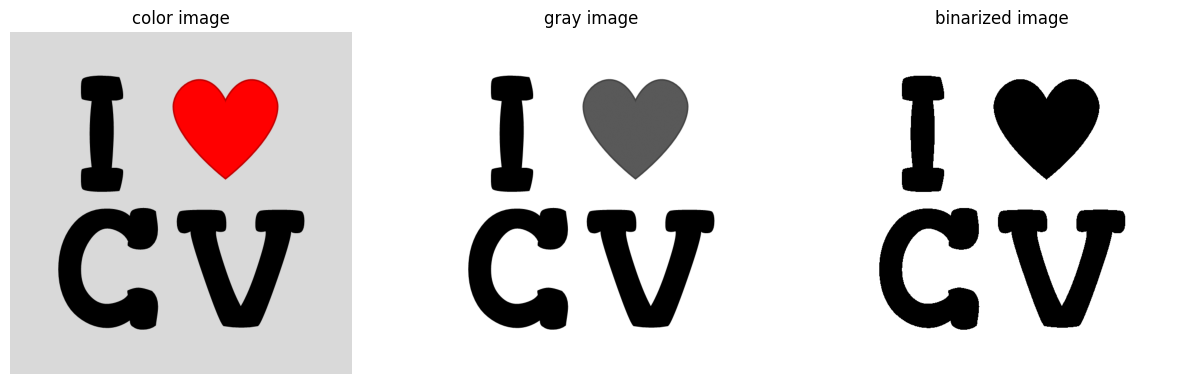

In [13]:
# function for image thresholding
def imThreshold(img, threshold, maxVal):
    assert len(img.shape) == 2 # input image has to be gray

    height, width = img.shape
    bi_img = np.zeros((height, width), dtype=np.uint8)
    for x in range(height):
        for y in range(width):
            if img.item(x, y) > threshold:
                bi_img[x, y] = maxVal # change --> assign values using array indexing

    return bi_img

# read the image for local directory (same with this .ipynb)
img = cv2.imread('SourceImages/IloveCV.png')

# convert a color image to gray
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# image thresholding using global tresholder
img_bi = imThreshold(img_gray, 127, 255)

# Be sure to convert the color space of the image from
# BGR (Opencv) to RGB (Matplotlib) before you show a
# color image read from OpenCV
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('color image')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gray, 'gray')
plt.title('gray image')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_bi, 'gray')
plt.title('binarized image')
plt.axis("off")

plt.show()

## Description
---

## HW1 Problems  - Part 1 : (35 pts)
---

- **Problem 1.1 Gaussian filter {10 pts}:**

  (a) Write a function that takes two arguments, a width parameter and a sigma parameter, and returns a 2D array containing a Gaussian kernel of the desired dimension and variance. The peak of the Gaussian should be in the center of the array. Make sure to normalize the kernel such that the sum of all the elements in the array is 1. Use this function and the OpenCV’s `filter2D` routine to convolve the image and noisy image arrays with a 5x5 Gaussian kernel of sigma=1 and a 11x11 Gaussian kernel of sigma=2. There will be four output images from this problem, namely, image convolved with 5x5, and 11x11, noisy image convolved with 5x5, and 11x11.

  (b) Write a function that takes an image and its noisy version, and return the Peak Signal-to-Noise Ratio (PSNR) value. Refer to https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio for its mathematical form. Pay attention that you might need to do convertion between different data types.

  Once you fill in and run the codes, the outputs will be saved under `Results` folder. Also images will be displayed in the notebook with PSNR marked in the titles. Please only fill in the missing part as indicated by `##########--WRITE YOUR CODE HERE--##########` and do not modify other parts. The grading for this question will be based on the ground-truth PSNR and your results.

  Lena image is credit to https://www.ece.rice.edu/~wakin/images/.

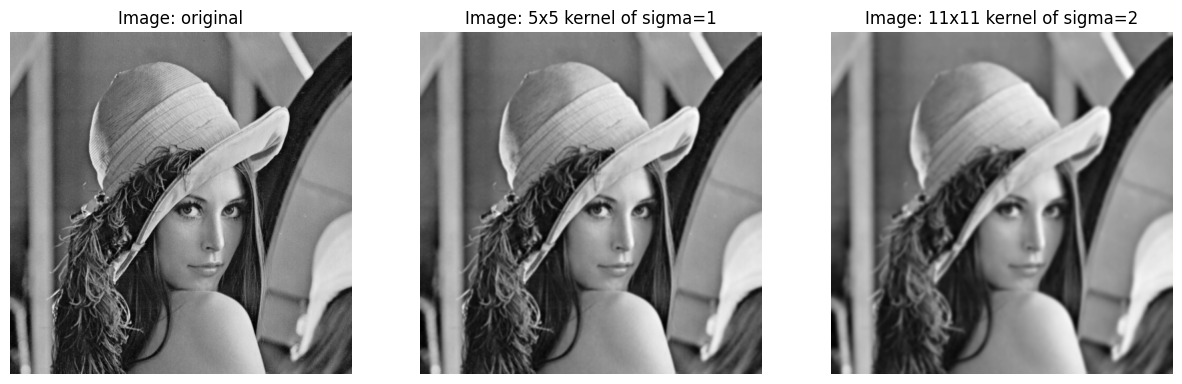

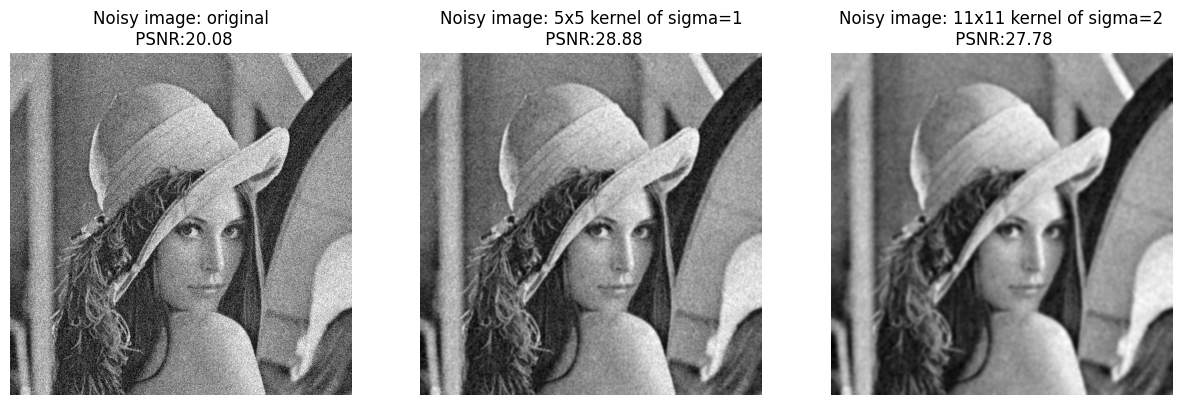

In [14]:
def genGaussianKernel(width, sigma):
    ##########--WRITE YOUR CODE HERE--##########
    assert width % 2 == 1  # width should be odd so the peak is centered

    k = width // 2
    x = np.arange(-k, k + 1)
    y = np.arange(-k, k + 1)
    X, Y = np.meshgrid(x, y)

    kernel_2d = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    kernel_2d = kernel_2d / np.sum(kernel_2d)  # normalize so sum is 1
    ##########--WRITE YOUR CODE HERE--##########

    return kernel_2d

def PSNR(img, img_noise, max_pixel_value=255):
    ##########--WRITE YOUR CODE HERE--##########
    img = img.astype(np.float32)
    img_noise = img_noise.astype(np.float32)

    mse = np.mean((img - img_noise) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 10 * np.log10((max_pixel_value ** 2) / mse)
    ##########--WRITE YOUR CODE HERE--##########

    return psnr

# Function to generate image with Gaussian noise
def addGaussianNoise(img, mean, std, seed=0):
    # suppose the input image is 2D gray image
    np.random.seed(seed)
    img_noise = img.astype(np.float32)/255.
    noise = np.random.normal(mean, std, img.shape)
    img_noise = img_noise + noise
    img_noise = np.clip(img_noise, 0., 1.)
    img_noise = (img_noise*255).astype(np.uint8)
    return img_noise

# Load images
img = cv2.imread('SourceImages/lena512.bmp', 0)

# Add Gaussian Noise
img_gnoise = addGaussianNoise(img, 0, 0.1)
PSNR_img_gnoise = PSNR(img, img_gnoise)

# Generate Gaussian kernels
kernel_1 = genGaussianKernel(5, 1)  # 5x5 kernel of sigma=1
kernel_2 = genGaussianKernel(11, 2)  # 11x11 kernel of sigma=2

# Convolve kernel with (noisy) image
img_kernel1 = cv2.filter2D(img, -1, kernel_1)
img_kernel2 = cv2.filter2D(img, -1, kernel_2)
img_gnoise_kernel1 = cv2.filter2D(img_gnoise, -1, kernel_1)
img_gnoise_kernel2 = cv2.filter2D(img_gnoise, -1, kernel_2)

PSNR_img_gnoise_kernel1 = PSNR(img, img_gnoise_kernel1)
PSNR_img_gnoise_kernel2 = PSNR(img, img_gnoise_kernel2)

# Write result images
if not os.path.exists("Results"):
  os.makedirs("Results")
cv2.imwrite("Results/P1_01.jpg", img_kernel1)
cv2.imwrite("Results/P1_02.jpg", img_kernel2)
cv2.imwrite("Results/P1_03.jpg", img_gnoise_kernel1)
cv2.imwrite("Results/P1_04.jpg", img_gnoise_kernel2)

# Plot results
plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, 'gray')
plt.title('Image: original')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_kernel1, 'gray')
plt.title('Image: 5x5 kernel of sigma=1')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_kernel2, 'gray')
plt.title('Image: 11x11 kernel of sigma=2')
plt.axis("off")

plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_gnoise, 'gray')
plt.title('Noisy image: original\n PSNR:{0:.2f}'.format(PSNR_img_gnoise))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gnoise_kernel1, 'gray')
plt.title('Noisy image: 5x5 kernel of sigma=1\n PSNR:{0:.2f}'
                        .format(PSNR_img_gnoise_kernel1))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_gnoise_kernel2, 'gray')
plt.title('Noisy image: 11x11 kernel of sigma=2\n PSNR:{0:.2f}'
                        .format(PSNR_img_gnoise_kernel2))
plt.axis("off")

plt.show()

- **Problem 1.2 Median filter {10 pts}:** \\
(a) Write a function to generate an image with salt and pepper noise. The function takes three arguments, the input image, the probability that a pixel location has salt-pepper noise and a random seed for repitability. A simple implementation can be to select pixel locations with probability 'p' where noise occurs and then with equal probability set the pixel value at those location to be 0 or 255.(**Hint: Use np.random.uniform and np.random.choice**)

 (b) Write a function to implement a median filter. The function takes two arguments, an image and a window size (if window size is 'k', then a kxk window is used to determine the median pixel value at a location) and returns the output image. **Do not** use any inbuilt library (like scipy.ndimage_filter) to directly generate the result. (**Hint: Use cv2.copyMakeBorder to add borders**)  

 You need to generate two noisy images corrupted by salt-and-pepper noise with noise probability equals 0.1 and 0.2. And then use median filter of window size=5 to denoise the two noisy images. You also need to denoise them with Gaussian filters. Try different parameters of Gaussian filters to get as higher PSNR as possible. Fill in all the missing parts and do not modify others.


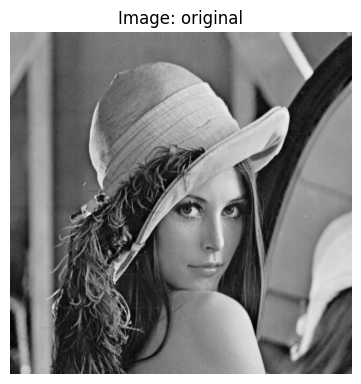

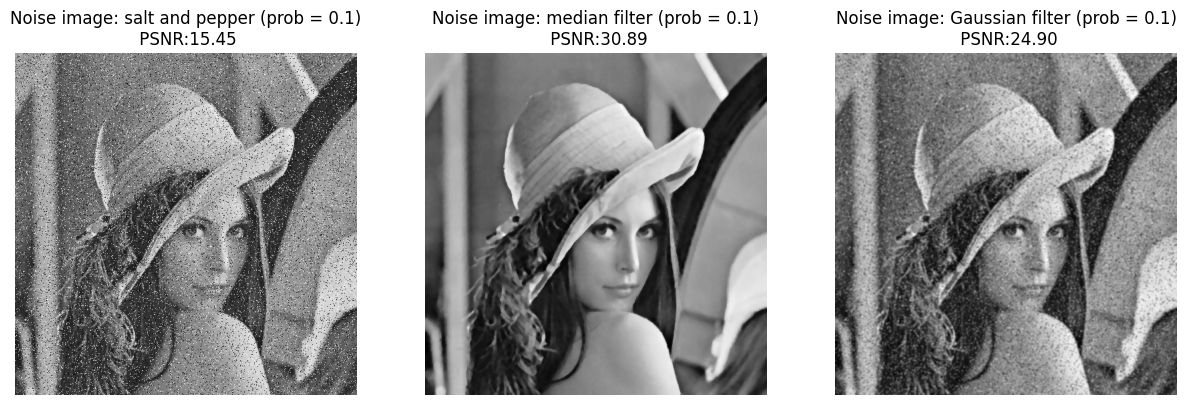

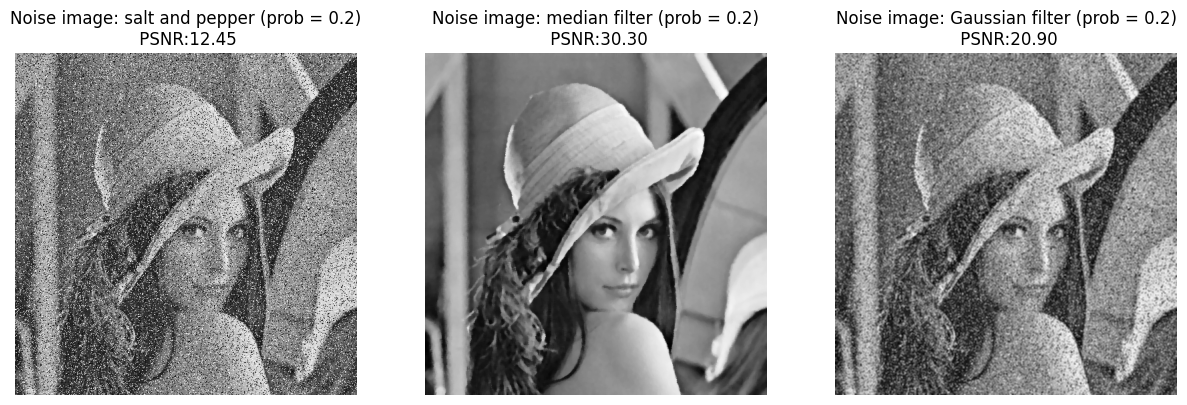

In [16]:
# Function to generate image with salt and pepper noise
def addSaltPepperNoise(img, prob = 0.1, seed=0):
  # suppose the input image is 2D gray image
  # with probability=prob each pixel is replaced with a pepper(0) or a salt(255) in equal chance
  np.random.seed(seed)
  ##########--WRITE YOUR CODE HERE--##########
  img_noise = img.copy()

  mask = np.random.uniform(0, 1, img.shape) < prob  # locations where noise occurs
  sp_values = np.random.choice([0, 255], size=img.shape)  # pepper or salt with equal probability

  img_noise[mask] = sp_values[mask]
  ##########--WRITE YOUR CODE HERE--##########
  return img_noise

# Function to apply median filter (window size kxk) on the input image
def medianFilter(img, window_size = 5):
  ##########--WRITE YOUR CODE HERE--##########
  assert window_size % 2 == 1  # window size should be odd

  pad = window_size // 2
  img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT)

  height, width = img.shape
  filtered_image = np.zeros((height, width), dtype=img.dtype)

  for x in range(height):
    for y in range(width):
      window = img_pad[x:x + window_size, y:y + window_size]
      filtered_image[x, y] = np.median(window)
  ##########--WRITE YOUR CODE HERE--##########

  return filtered_image


img_spnoise_p1 = addSaltPepperNoise(img, 0.1)
PSNR_img_spnoise_p1 = PSNR(img, img_spnoise_p1)

img_spnoise_p1_MedianFilter = medianFilter(img_spnoise_p1, 5)
PSNR_img_spnoise_p1_MedianFilter =  PSNR(img, img_spnoise_p1_MedianFilter)

img_spnoise_p2 = addSaltPepperNoise(img, 0.2)
PSNR_img_spnoise_p2 = PSNR(img, img_spnoise_p2)

img_spnoise_p2_MedianFilter = medianFilter(img_spnoise_p2, 5)
PSNR_img_spnoise_p2_MedianFilter = PSNR(img, img_spnoise_p2_MedianFilter)

# Generate Gaussian kernels
kernel_1 = genGaussianKernel(5, 1)  ##########---------##########
kernel_2 =genGaussianKernel(3, 2)   ##########---------##########

# Convolve filters with image and noisy image
img_spnoise_p1_GaussianFilter = cv2.filter2D(img_spnoise_p1, -1, kernel_1)
PSNR_img_spnoise_p1_GaussianFilter = PSNR(img, img_spnoise_p1_GaussianFilter)

img_spnoise_p2_GaussianFilter = cv2.filter2D(img_spnoise_p2, -1, kernel_2)
PSNR_img_spnoise_p2_GaussianFilter = PSNR(img, img_spnoise_p2_GaussianFilter)

cv2.imwrite("Results/P1_05.jpg", img_spnoise_p1_MedianFilter)
cv2.imwrite("Results/P1_06.jpg", img_spnoise_p1_GaussianFilter)
cv2.imwrite("Results/P1_07.jpg", img_spnoise_p2_MedianFilter)
cv2.imwrite("Results/P1_08.jpg", img_spnoise_p2_GaussianFilter)

# Plot results
plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, 'gray')
plt.title('Image: original')
plt.axis("off")

plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_spnoise_p1, 'gray')
plt.title('Noise image: salt and pepper (prob = 0.1)\n PSNR:{0:.2f}'
                .format(PSNR_img_spnoise_p1))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_spnoise_p1_MedianFilter, 'gray')
plt.title('Noise image: median filter (prob = 0.1)\n PSNR:{0:.2f}'
                .format(PSNR_img_spnoise_p1_MedianFilter))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_spnoise_p1_GaussianFilter, 'gray')
plt.title('Noise image: Gaussian filter (prob = 0.1)\n PSNR:{0:.2f}'
                .format(PSNR_img_spnoise_p1_GaussianFilter))
plt.axis("off")

plt.figure(figsize = (15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_spnoise_p2, 'gray')
plt.title('Noise image: salt and pepper (prob = 0.2)\n PSNR:{0:.2f}'
                .format(PSNR_img_spnoise_p2))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_spnoise_p2_MedianFilter, 'gray')
plt.title('Noise image: median filter (prob = 0.2)\n PSNR:{0:.2f}'
                .format(PSNR_img_spnoise_p2_MedianFilter))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_spnoise_p2_GaussianFilter, 'gray')
plt.title('Noise image: Gaussian filter (prob = 0.2)\n PSNR:{0:.2f}'
                  .format(PSNR_img_spnoise_p2_GaussianFilter))
plt.axis("off")
plt.show()

- **Problem 1.3 Bilateral Filter  {15 pts}:**   

Start with the following tutorials:
https://en.wikipedia.org/wiki/Bilateral_filter

A bilateral filter includes a range kernel and a spatial kernel. Both kernels are Gaussian kernels on different domains. In this problem, the std of the range kernel is set for [0, 255] intensity range. So keep the padded input image as int dtype in [0, 255]. Following the tutorial, we first get the unnormalized version of the two kernels and then jointly normalize the combined kernel for each pixel. The results might be slightly different from the reference result.

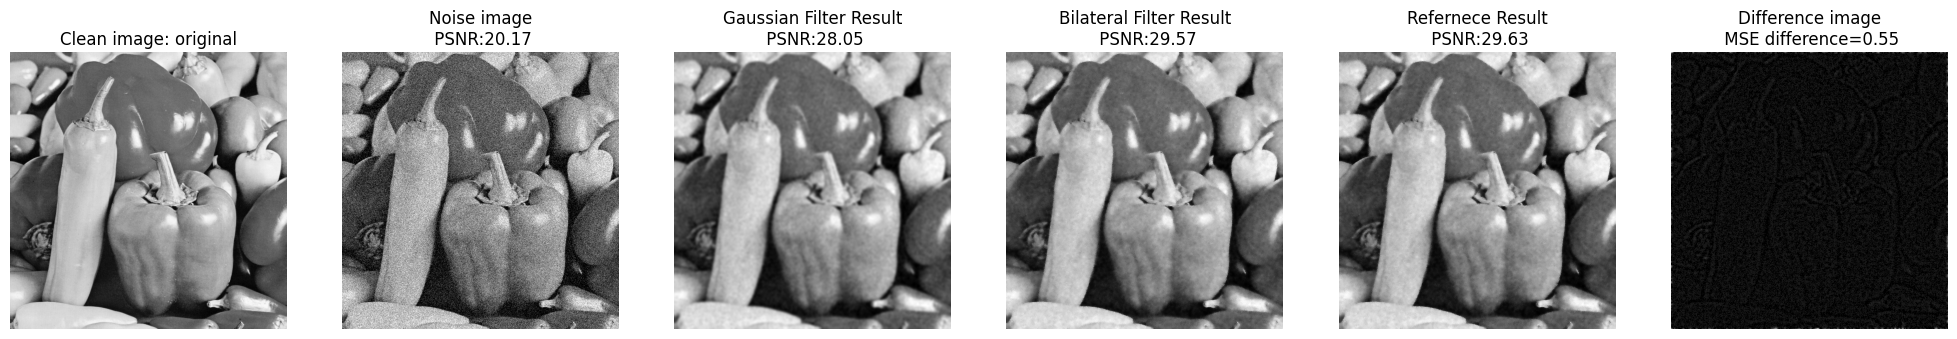

In [17]:
d = 11  # diameter
sigma_r = 75.  # sigma_r is for [0, 255] intensity range
sigma_s = 2.

img_bi = cv2.imread('SourceImages/peppers.bmp', 0)
img_noisy = addGaussianNoise(img_bi, 0, 0.1)

# calculate the unnormalized range kernel for the input (square) patch and its center pixel
def range_kernel(patch, sigma_r):
    center_value = patch[len(patch) // 2, len(patch) // 2]  # center pixel value
    diff = patch - center_value
    kernel_r = np.exp(-(diff**2) / (2 * sigma_r**2))  # Gaussian range kernel
    return kernel_r

# calculate the unnormalized spatial kernel
def spatial_kernel(d, sigma_s):
    kernel_s = np.zeros((d, d))
    center = d // 2
    for i in range(d):
        for j in range(d):
            dist = (i - center)**2 + (j - center)**2
            kernel_s[i, j] = np.exp(-dist / (2 * sigma_s**2))  # Gaussian spatial kernel
    return kernel_s

# function of applying bilateral filter to an image
# Note: remember to jointly normalize the two kernels for each pixel
def bilateral_filter(img, d, sigma_r, sigma_s):
    pad = d // 2

    # keep padded image as int dtype in [0, 255] range
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT).astype(np.int32)

    height, width = img.shape
    result = np.zeros((height, width), dtype=np.float32)

    # spatial kernel is fixed for all pixels
    kernel_s = spatial_kernel(d, sigma_s)

    for x in range(height):
        for y in range(width):
            patch = img_pad[x:x + d, y:y + d]  # dxd patch around (x, y)

            # range kernel depends on center intensity of this patch
            kernel_r = range_kernel(patch, sigma_r)

            # combined kernel, then normalize jointly per pixel
            kernel = kernel_s * kernel_r
            kernel = kernel / np.sum(kernel)

            result[x, y] = np.sum(kernel * patch)

    # keep values in valid range
    result = np.clip(result, 0, 255)

    return result

img_dn = bilateral_filter(img_noisy, d, sigma_r, sigma_s).astype('uint8')
img_ref = cv2.bilateralFilter(img_noisy, d, sigma_r, sigma_s)
img_gauss = cv2.GaussianBlur(img_noisy, (d, d), sigma_s)

img_diff = np.abs(img_dn.astype('int') - img_ref.astype('int')).astype('uint8')

# Plot the results
fig = plt.figure(figsize=(25, 5))
plt.subplot(1, 6, 1)
plt.imshow(img_bi, 'gray')
plt.title('Clean image: original')
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(img_noisy, 'gray')
plt.title('Noise image\n PSNR:{0:.2f}'
                        .format(PSNR(img_bi, img_noisy)))
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(img_gauss, 'gray')
plt.title('Gaussian Filter Result\n PSNR:{0:.2f}'
                        .format(PSNR(img_bi, img_gauss)))
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(img_dn, 'gray')
plt.title('Bilateral Filter Result\n PSNR:{0:.2f}'
                        .format(PSNR(img_bi, img_dn)))
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(img_ref, 'gray')
plt.title('Refernece Result\n PSNR:{0:.2f}'
                        .format(PSNR(img_bi, img_ref)))
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(img_diff, 'gray')
plt.title('Difference image\n MSE difference={0:.2f}'
                        .format(np.mean(img_diff**2)))
plt.axis("off")

cv2.imwrite("Results/P1_09.jpg", img_dn);